# Caso de estudio: Marketing Mix Modeling aplicado
### De OLS a Ridge — entendiendo lo que hace Robyn por dentro

Este notebook usa un dataset **simulado** (pero realista) de inversión semanal en Meta Ads, Google Ads, DV360 y TikTok durante 2 años, junto con las ventas resultantes.

La idea es que repliques, paso a paso y con tus propias manos, el mismo problema que resuelve Robyn: **saber cuánto le aporta cada canal a las ventas, cuando los canales suben y bajan presupuesto juntos** (multicolinealidad).

**Estructura:**
1. Explorar los datos y confirmar el problema (correlación entre canales)
2. Correr una regresión lineal normal (OLS) y ver por qué falla
3. Corregir con Ridge regression (lo que usa Robyn) y comparar
4. Interpretar los coeficientes en términos de negocio (contribución y retorno por canal)
5. Evaluar el modelo (R², residuos)

> Requisitos: `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `statsmodels`.
> Si no los tienes instalados: `pip install pandas numpy matplotlib scikit-learn statsmodels`
> También puedes subir este notebook a [Google Colab](https://colab.research.google.com/) sin instalar nada localmente.


## 1. Cargar y explorar los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("caso_estudio_mmm.csv", parse_dates=["semana"])
df.head()


,semana,meta_spend,google_spend,dv360_spend,tiktok_spend,ventas
0,2024-01-01,8298.0,5919.0,4206.0,2789.0,78929.0
1,2024-01-08,8094.0,6335.0,5630.0,2840.0,76772.0
2,2024-01-15,8741.0,7207.0,4404.0,3067.0,81258.0
3,2024-01-22,9436.0,6479.0,4716.0,2671.0,78519.0
4,2024-01-29,8546.0,6644.0,4725.0,2953.0,83308.0


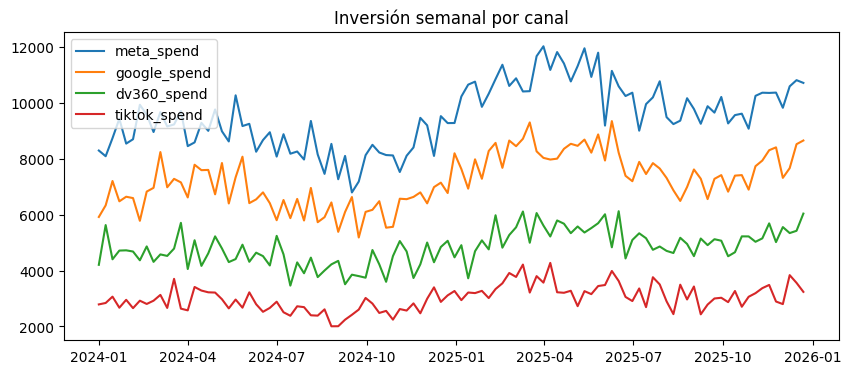

In [2]:
# Visualicemos la inversión por canal a lo largo del tiempo
fig, ax = plt.subplots(figsize=(10, 4))
for canal in ["meta_spend", "google_spend", "dv360_spend", "tiktok_spend"]:
    ax.plot(df["semana"], df[canal], label=canal)
ax.set_title("Inversión semanal por canal")
ax.legend()
plt.show()


Fíjate en el patrón: **todos los canales suben y bajan juntos** (más presupuesto en ciertas épocas, menos en otras). Esto es exactamente lo que pasa en la vida real — nadie sube el budget de Meta y baja el de Google al mismo tiempo sin razón. Ese movimiento conjunto es lo que genera multicolinealidad.

In [3]:
# Matriz de correlación entre canales
corr = df[["meta_spend", "google_spend", "dv360_spend", "tiktok_spend"]].corr()
print(corr.round(2))

# VIF (Variance Inflation Factor): mide qué tan "explicado" está cada canal
# por los otros canales. VIF > 5 (algunos dicen >10) es señal de alerta.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[["meta_spend", "google_spend", "dv360_spend", "tiktok_spend"]]
vif_data = pd.DataFrame()
vif_data["canal"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n", vif_data)


              meta_spend  google_spend  dv360_spend  tiktok_spend
meta_spend          1.00          0.79         0.65          0.65
google_spend        0.79          1.00         0.66          0.69
dv360_spend         0.65          0.66         1.00          0.55
tiktok_spend        0.65          0.69         0.55          1.00



           canal       VIF
0    meta_spend  3.029004
1  google_spend  3.382979
2   dv360_spend  1.944965
3  tiktok_spend  2.025895


**Lectura:** si ves VIFs altos (por ejemplo, arriba de 5), significa que el modelo va a tener problemas para separar el efecto individual de cada canal — que es justo lo que vamos a comprobar en el siguiente paso.

## 2. Regresión lineal normal (OLS) — y por qué falla

Corremos primero una regresión de mínimos cuadrados (OLS), como la que verías en el curso de Los Andes o en el proyecto de Coursera que te recomendé.

In [4]:
import statsmodels.api as sm

X = df[["meta_spend", "google_spend", "dv360_spend", "tiktok_spend"]]
y = df["ventas"]

X_const = sm.add_constant(X)
modelo_ols = sm.OLS(y, X_const).fit()
print(modelo_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     38.21
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           2.64e-19
Time:                        03:43:27   Log-Likelihood:                -988.50
No. Observations:                 104   AIC:                             1987.
Df Residuals:                      99   BIC:                             2000.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4.317e+04   2953.772     14.617   

**Qué mirar aquí:**
- Revisa el **R²** (qué tan bien explica el modelo las ventas en general).
- Revisa los **p-values** de cada canal (columna `P>|t|`) — si alguno sale muy alto (ej. > 0.05), el modelo no está seguro del efecto de ese canal.
- Revisa el **signo de los coeficientes**. Es común que en un caso con multicolinealidad alta, algún canal salga con coeficiente **negativo o inestable**, aunque sepamos que en realidad todos los canales ayudan a las ventas — eso es la multicolinealidad "robándole" varianza a otro canal correlacionado. Este es el problema real que Robyn evita usando Ridge.


## 3. Regresión Ridge — lo que hace Robyn por dentro

Ridge no elimina la correlación entre canales, pero **penaliza** los coeficientes para que no se disparen ni se vuelvan inestables por la multicolinealidad. El resultado es un set de coeficientes más realista y estable.

In [5]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# Ridge es sensible a la escala de las variables -> estandarizamos primero
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RidgeCV prueba varios valores de alpha (fuerza de la penalización)
# y elige el mejor por validación cruzada -- así no lo adivinamos a ojo.
alphas = np.logspace(-2, 4, 100)
modelo_ridge = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y)

print("Alpha óptimo elegido por validación cruzada:", modelo_ridge.alpha_)

coef_ridge = pd.Series(modelo_ridge.coef_, index=X.columns)
print("\nCoeficientes Ridge (estandarizados):")
print(coef_ridge.round(2))


Alpha óptimo elegido por validación cruzada: 10.722672220103231

Coeficientes Ridge (estandarizados):
meta_spend       755.05
google_spend    1859.27
dv360_spend     1037.49
tiktok_spend     765.09
dtype: float64


              OLS (coef. original)  Ridge (coef. estandarizado)
meta_spend                0.493240                   755.045609
google_spend              2.428860                  1859.266453
dv360_spend               1.705248                  1037.490745
tiktok_spend              1.551479                   765.087982


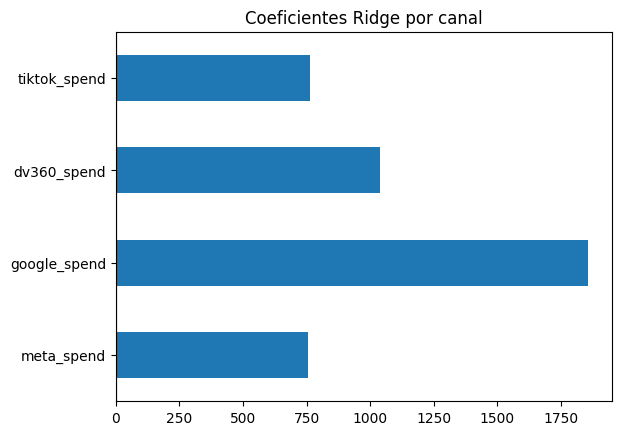

In [6]:
# Comparación directa: OLS vs Ridge
comparacion = pd.DataFrame({
    "OLS (coef. original)": modelo_ols.params[1:],
    "Ridge (coef. estandarizado)": coef_ridge
})
print(comparacion)

comparacion["Ridge (coef. estandarizado)"].plot(kind="barh", title="Coeficientes Ridge por canal")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


**Qué comparar:** los coeficientes de OLS no son directamente comparables entre sí (porque cada canal tiene una escala de inversión distinta), mientras que los de Ridge (estandarizados) sí te dejan comparar **qué canal tiene mayor impacto relativo en ventas** de forma más confiable, sin que la multicolinealidad distorsione el resultado.

## 4. Interpretación en términos de negocio

Esta es la parte que más le importa a un cliente o a tu jefe: no los coeficientes en sí, sino **qué significan para la inversión**.

Contribución promedio semanal estimada por canal (unidades de venta):
meta_spend       4697.0
google_spend    17569.0
dv360_spend      8229.0
tiktok_spend     4681.0
dtype: float64


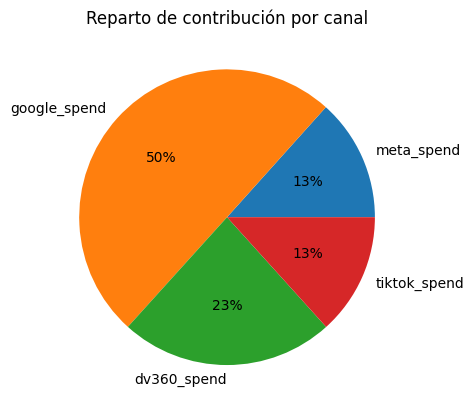

In [7]:
# Contribución total estimada por canal (usando el modelo Ridge sobre datos reales, no estandarizados)
from sklearn.linear_model import Ridge

modelo_ridge_original = Ridge(alpha=modelo_ridge.alpha_).fit(X, y)
contribucion_promedio_semanal = pd.Series(
    modelo_ridge_original.coef_ * X.mean().values,
    index=X.columns
)

print("Contribución promedio semanal estimada por canal (unidades de venta):")
print(contribucion_promedio_semanal.round(0))

contribucion_promedio_semanal.plot(kind="pie", autopct="%1.0f%%", title="Reparto de contribución por canal")
plt.ylabel("")
plt.show()


**Pregunta de negocio que ya puedes responder con esto:**
> "¿Qué canal me está dando más retorno por peso invertido, y dónde debería mover presupuesto?"

Compara la contribución de cada canal contra lo que se invierte en él (`X.mean()`) — un canal con **alta contribución pero baja inversión relativa** es candidato a recibir más presupuesto; uno con **baja contribución y alta inversión** es candidato a revisar.


In [8]:
# Retorno relativo aproximado: contribución / inversión promedio
retorno_relativo = contribucion_promedio_semanal / X.mean()
print("Retorno relativo estimado por canal (ventas generadas por unidad de inversión):")
print(retorno_relativo.round(2).sort_values(ascending=False))


Retorno relativo estimado por canal (ventas generadas por unidad de inversión):
google_spend    2.43
dv360_spend     1.71
tiktok_spend    1.55
meta_spend      0.49
dtype: float64


## 5. Evaluación del modelo

Antes de confiar en cualquier conclusión de negocio, siempre valida qué tan bien ajusta el modelo.

R² del modelo Ridge: 0.607
R² del modelo OLS:   0.607


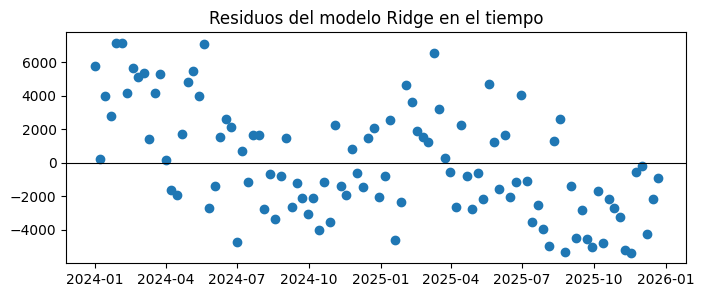

In [9]:
from sklearn.metrics import r2_score

pred_ridge = modelo_ridge_original.predict(X)
print("R² del modelo Ridge:", round(r2_score(y, pred_ridge), 3))
print("R² del modelo OLS:  ", round(modelo_ols.rsquared, 3))

# Residuos: deberían verse dispersos sin patrón (si hay un patrón claro, el modelo se está perdiendo algo)
residuos = y - pred_ridge
plt.figure(figsize=(8, 3))
plt.scatter(df["semana"], residuos)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Residuos del modelo Ridge en el tiempo")
plt.show()


## Siguiente paso: prueba esto con tus propios datos

Este mismo flujo (correlación → VIF → OLS → Ridge → interpretación de contribución → evaluación de residuos) es **exactamente** lo que corriste en MullenLowe con Robyn, solo que aquí lo hiciste tú mismo, viendo cada paso por dentro.

Para llevarlo a un caso real:
1. Reemplaza el CSV por datos reales de inversión semanal/mensual por canal + tu métrica de negocio (ventas, leads, conversiones).
2. Si tienes pocos datos históricos (menos de ~52 semanas), considera usar datos mensuales en vez de semanales para tener suficientes observaciones.
3. Robyn añade dos cosas que este notebook simplifica: **adstock** (el efecto de un anuncio no es solo esta semana, se arrastra a las siguientes) y **saturación no lineal** más sofisticada. Si quieres, en un siguiente notebook podemos incorporar eso.
